In [ ]:
#import thư viện
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Khởi tạo dữ liệu đầu vào cho AND, OR, XNOR.
X = np.array([
  [0,0],
  [0,1],
  [1,0],
  [1,1]
])

In [ ]:
# Xây dựng hàm kích hoạt (Activation Function) sử dụng Sigmoid
def g(z):
  return 1 / (1 + np.exp(-z))

In [ ]:
# Định nghĩa perceptron AND
def AND(x):
  return g(20*x[0] + 20*x[1] - 30)

In [ ]:
# Định nghĩa perceptron OR
def OR(x):
  return g(20*x[0] + 20*x[1] - 10)

In [ ]:
# Định nghĩa perceptron (Not x1) and (Not x2)
def NAND_NOT(x):
  return g(-20*x[0] - 20*x[1] + 10)

In [ ]:
# Định nghĩa MLP XNOR – tổ hợp nhiều perceptron (MLP)
def XNOR(x):
  h1 = AND(x)
  h2 = NAND_NOT(x)
  return g(20*h1 + 20*h2 - 10)

In [ ]:
# Nhóm lại
functions = {
  "AND": AND,
  "OR": OR,
  "(¬x1  ¬x2)": NAND_NOT,
  "XNOR": XNOR
}

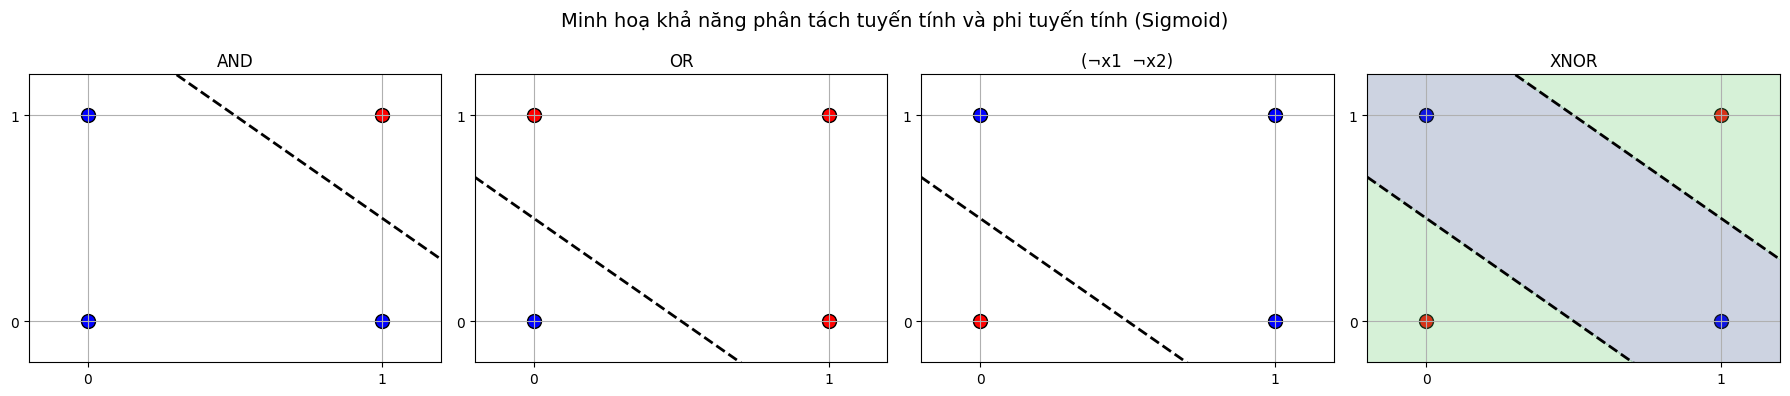

In [ ]:
# Vẽ điềm dữ liệu và các đường phân chia
fig, axes = plt.subplots(1, 4, figsize=(18,4))
xx = np.linspace(-0.2, 1.2, 400)

for ax, (name, func) in zip(axes, functions.items()):
  y = np.array([func(x) for x in X])

  # Plot data points (phân lớp dựa trên ngưỡng 0.5 cho Sigmoid)
  for p, val in zip(X, y):
    ax.scatter(
        p[0], p[1],
        color='red' if val >= 0.5 else 'blue',
        s=100,
        edgecolor='k'
    )

  # Vẽ đường phân chia
  if name == "AND":
    ax.plot(xx, 1.5 - xx, 'k--', linewidth=2)

  elif name in ["OR", "(¬x1  ¬x2)"]:
    ax.plot(xx, 0.5 - xx, 'k--', linewidth=2)

  elif name == "XNOR":
  # Two boundaries
    ax.plot(xx, 0.5 - xx, 'k--', linewidth=2)
    ax.plot(xx, 1.5 - xx, 'k--', linewidth=2)

    # Draw decision regions
    xxg, yyg = np.meshgrid(
        np.linspace(-0.2, 1.2, 300),
        np.linspace(-0.2, 1.2, 300)
    )

    Z = np.zeros_like(xxg)
    for i in range(xxg.shape[0]):
        for j in range(xxg.shape[1]):
            # Áp dụng ngưỡng 0.5 cho đầu ra Sigmoid
            Z[i, j] = 1 if XNOR([xxg[i, j], yyg[i, j]]) >= 0.5 else 0

    ax.contourf(
        xxg, yyg, Z,
        levels=[-0.1, 0.5, 1.1],
        alpha=0.25
    )

  ax.set_title(name, fontsize=12)
  ax.set_xlim(-0.2,1.2)
  ax.set_ylim(-0.2,1.2)
  ax.set_xticks([0,1])
  ax.set_yticks([0,1])
  ax.grid(True)

plt.suptitle("Minh hoạ khả năng phân tách tuyến tính và phi tuyến tính (Sigmoid)", fontsize=14)
plt.tight_layout()
plt.show()